## Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves summarizing the main characteristics of a dataset, often using visual methods. The goal of EDA is to gain insights into the data, identify patterns, detect anomalies, and formulate hypotheses for further analysis.

In [1]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [ ]:
# Extract the dataset from the zip file
import zipfile
with zipfile.ZipFile("../data/micro+gas+turbine+electrical+energy+prediction.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

In [3]:

# Extract the training dataset from the zip file
with zipfile.ZipFile("../data/train.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

# Extract the test dataset from the zip file
with zipfile.ZipFile("../data/test.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

In [2]:
# load the dataset
ex_1_df = pd.read_csv("../data/train/ex_1.csv")
ex_1_df.head()

,time,input_voltage,el_power
0,810.07028,10,1228.791720
1,811.06938,10,1223.041745
2,812.06848,10,1244.960866
3,813.06758,10,1229.259058
4,814.06668,10,1248.117024


In [3]:
# change the date column to datetime
ex_1_df["time"] = pd.to_datetime(ex_1_df["time"])
ex_1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9920 entries, 0 to 9919
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           9920 non-null   datetime64[ns]
 1   input_voltage  9920 non-null   int64         
 2   el_power       9920 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 232.6 KB


In [4]:
ex_1_df.describe()

,time,input_voltage,el_power
count,9920,9920.000000,9920.000000
mean,1970-01-01 00:00:00.000005764,6.822480,2162.427874
min,1970-01-01 00:00:00.000000810,3.000000,932.837260
25%,1970-01-01 00:00:00.000003286,3.000000,990.027512
50%,1970-01-01 00:00:00.000005764,10.000000,2709.354147
75%,1970-01-01 00:00:00.000008242,10.000000,3116.416457
max,1970-01-01 00:00:00.000010720,10.000000,3249.891217
std,NaN,3.485288,1009.468755


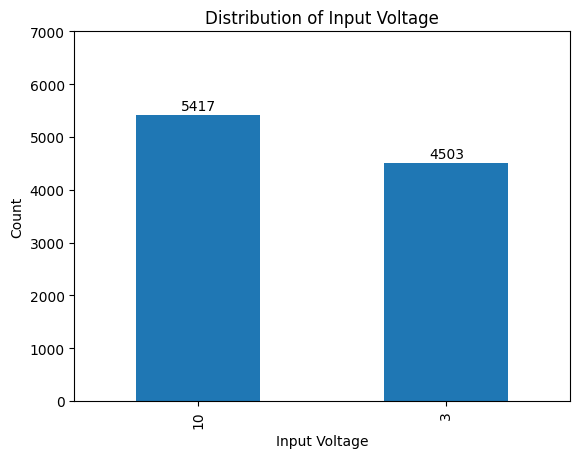

In [ ]:
ex_1_df.value_counts('input_voltage').plot(kind='bar')
plt.title('Distribution of Input Voltage')
plt.xlabel('Input Voltage')
plt.ylabel('Count')
plt.ylim(0, 7000)

for index, value in enumerate(ex_1_df.value_counts('input_voltage')):
    plt.text(index, value + 100, str(value), ha='center')

plt.show()

In [11]:
# Check time range
print(f"Time range: {ex_1_df['time'].min()} to {ex_1_df['time'].max()}")

Time range: 1970-01-01 00:00:00.000000810 to 1970-01-01 00:00:00.000010720


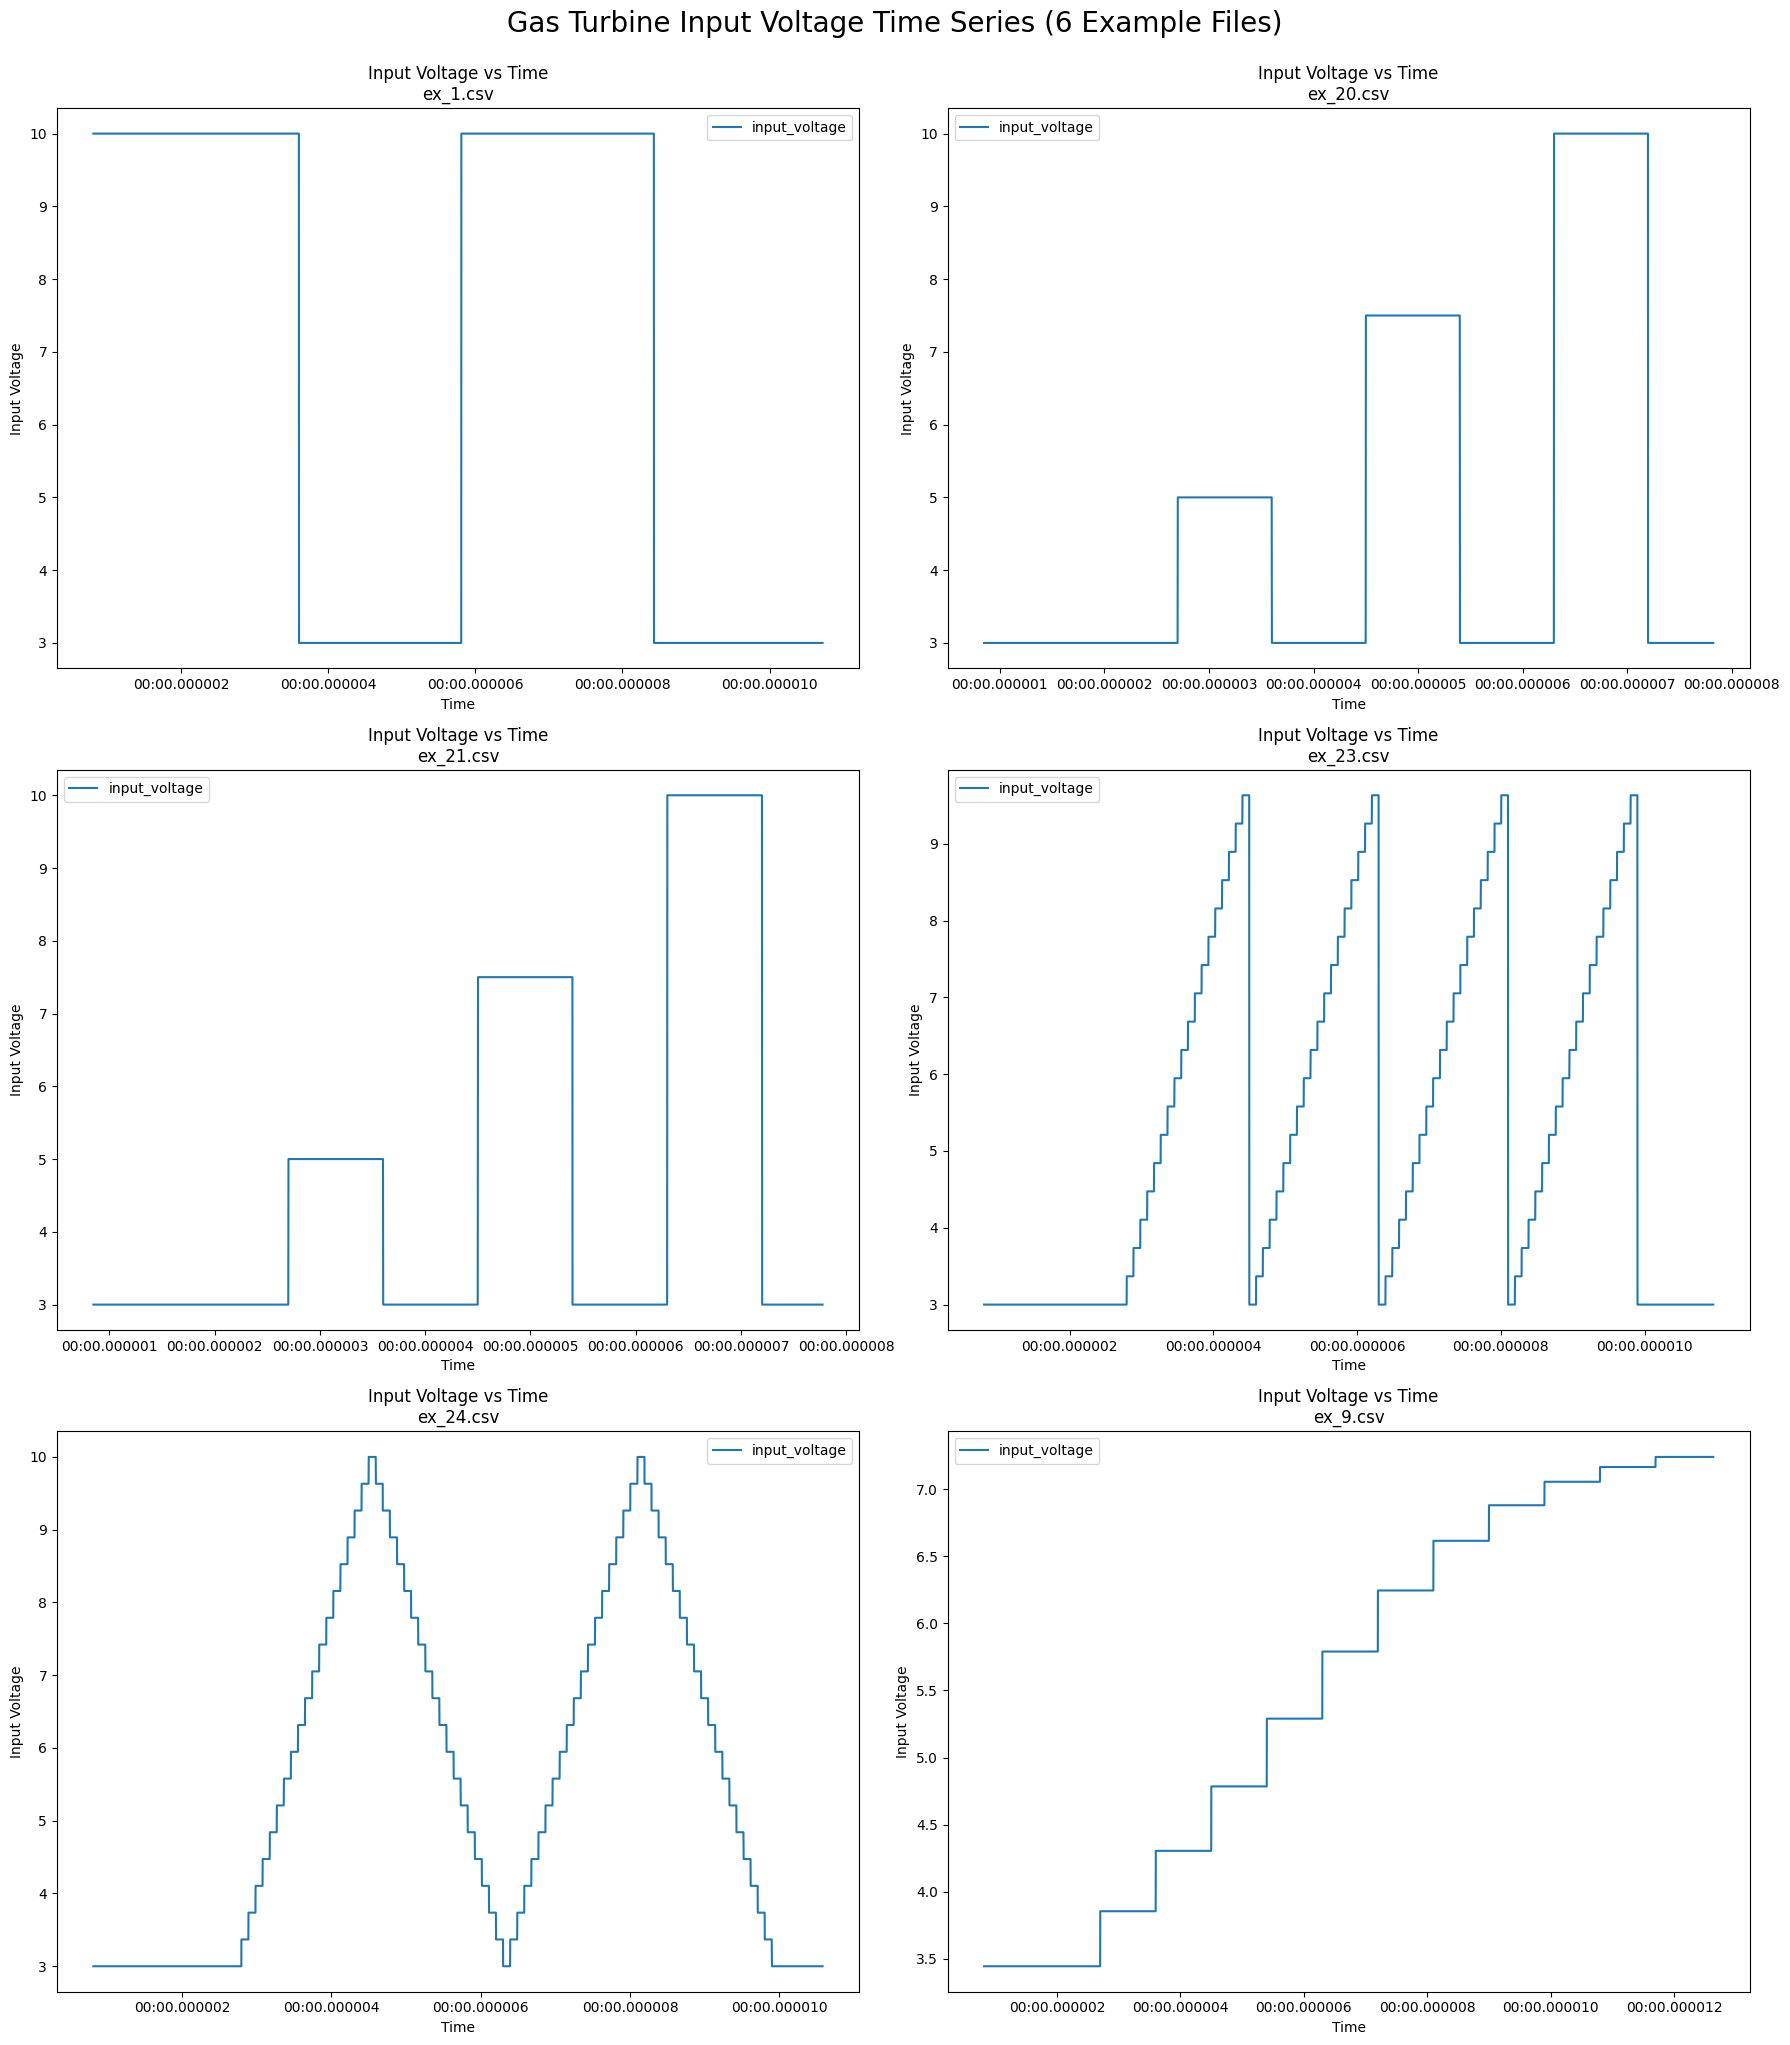

In [15]:
# High-level technical time series plots for 6 example files
import matplotlib.pyplot as plt
import pandas as pd
import glob
example_files = [
    '../data/train/ex_1.csv',
    '../data/train/ex_20.csv',
    '../data/train/ex_21.csv',
    '../data/train/ex_23.csv',
    '../data/train/ex_24.csv',
    '../data/train/ex_9.csv'
 ]

plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    data['time'] = pd.to_datetime(data['time'])
    plt.subplot(3, 2, i)
    plt.plot(data['time'], data['input_voltage'], label='input_voltage')
    plt.xlabel('Time')
    plt.ylabel('Input Voltage')
    plt.title(f'Input Voltage vs Time\n{file.split('/')[-1]}')
    plt.legend()
    plt.tight_layout()
plt.suptitle('Gas Turbine Input Voltage Time Series (6 Example Files)', fontsize=20, y=1.02)
plt.show()

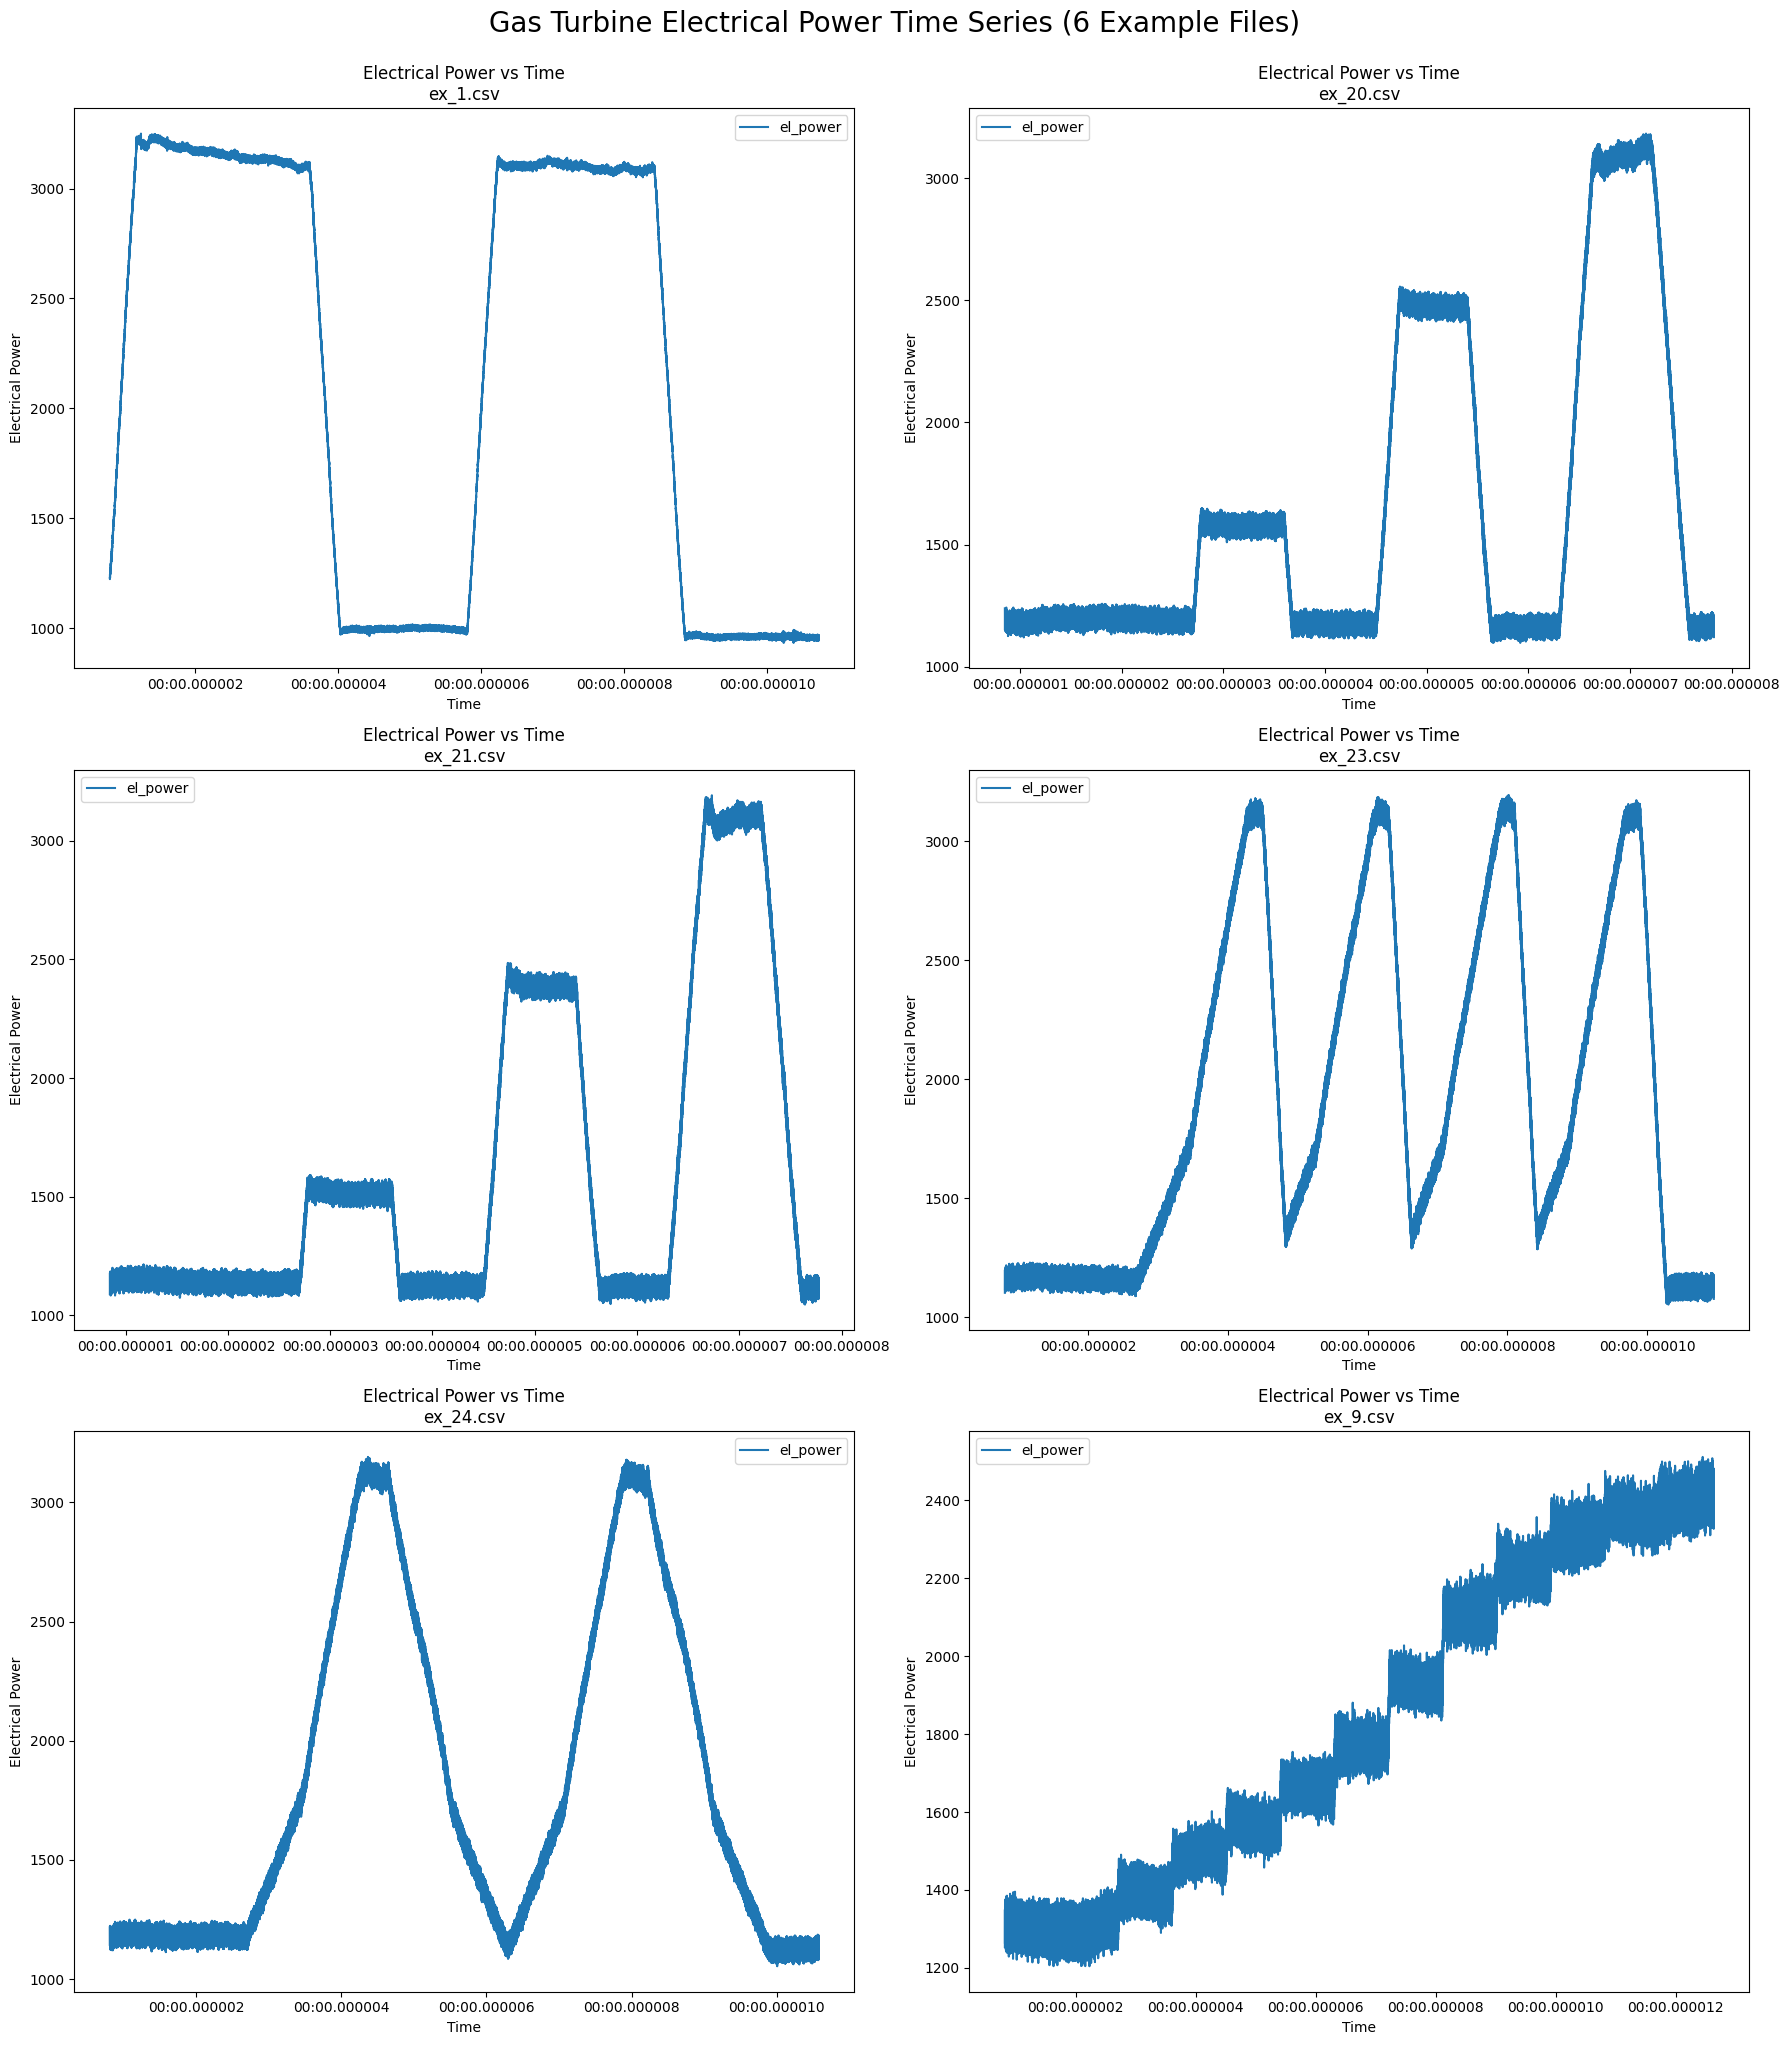

In [17]:
plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    data['time'] = pd.to_datetime(data['time'])
    plt.subplot(3, 2, i)
    plt.plot(data['time'], data['el_power'], label='el_power')
    plt.xlabel('Time')
    plt.ylabel('Electrical Power')
    plt.title(f'Electrical Power vs Time\n{file.split('/')[-1]}')
    plt.legend()
    plt.tight_layout()
plt.suptitle('Gas Turbine Electrical Power Time Series (6 Example Files)', fontsize=20, y=1.02)
plt.show()

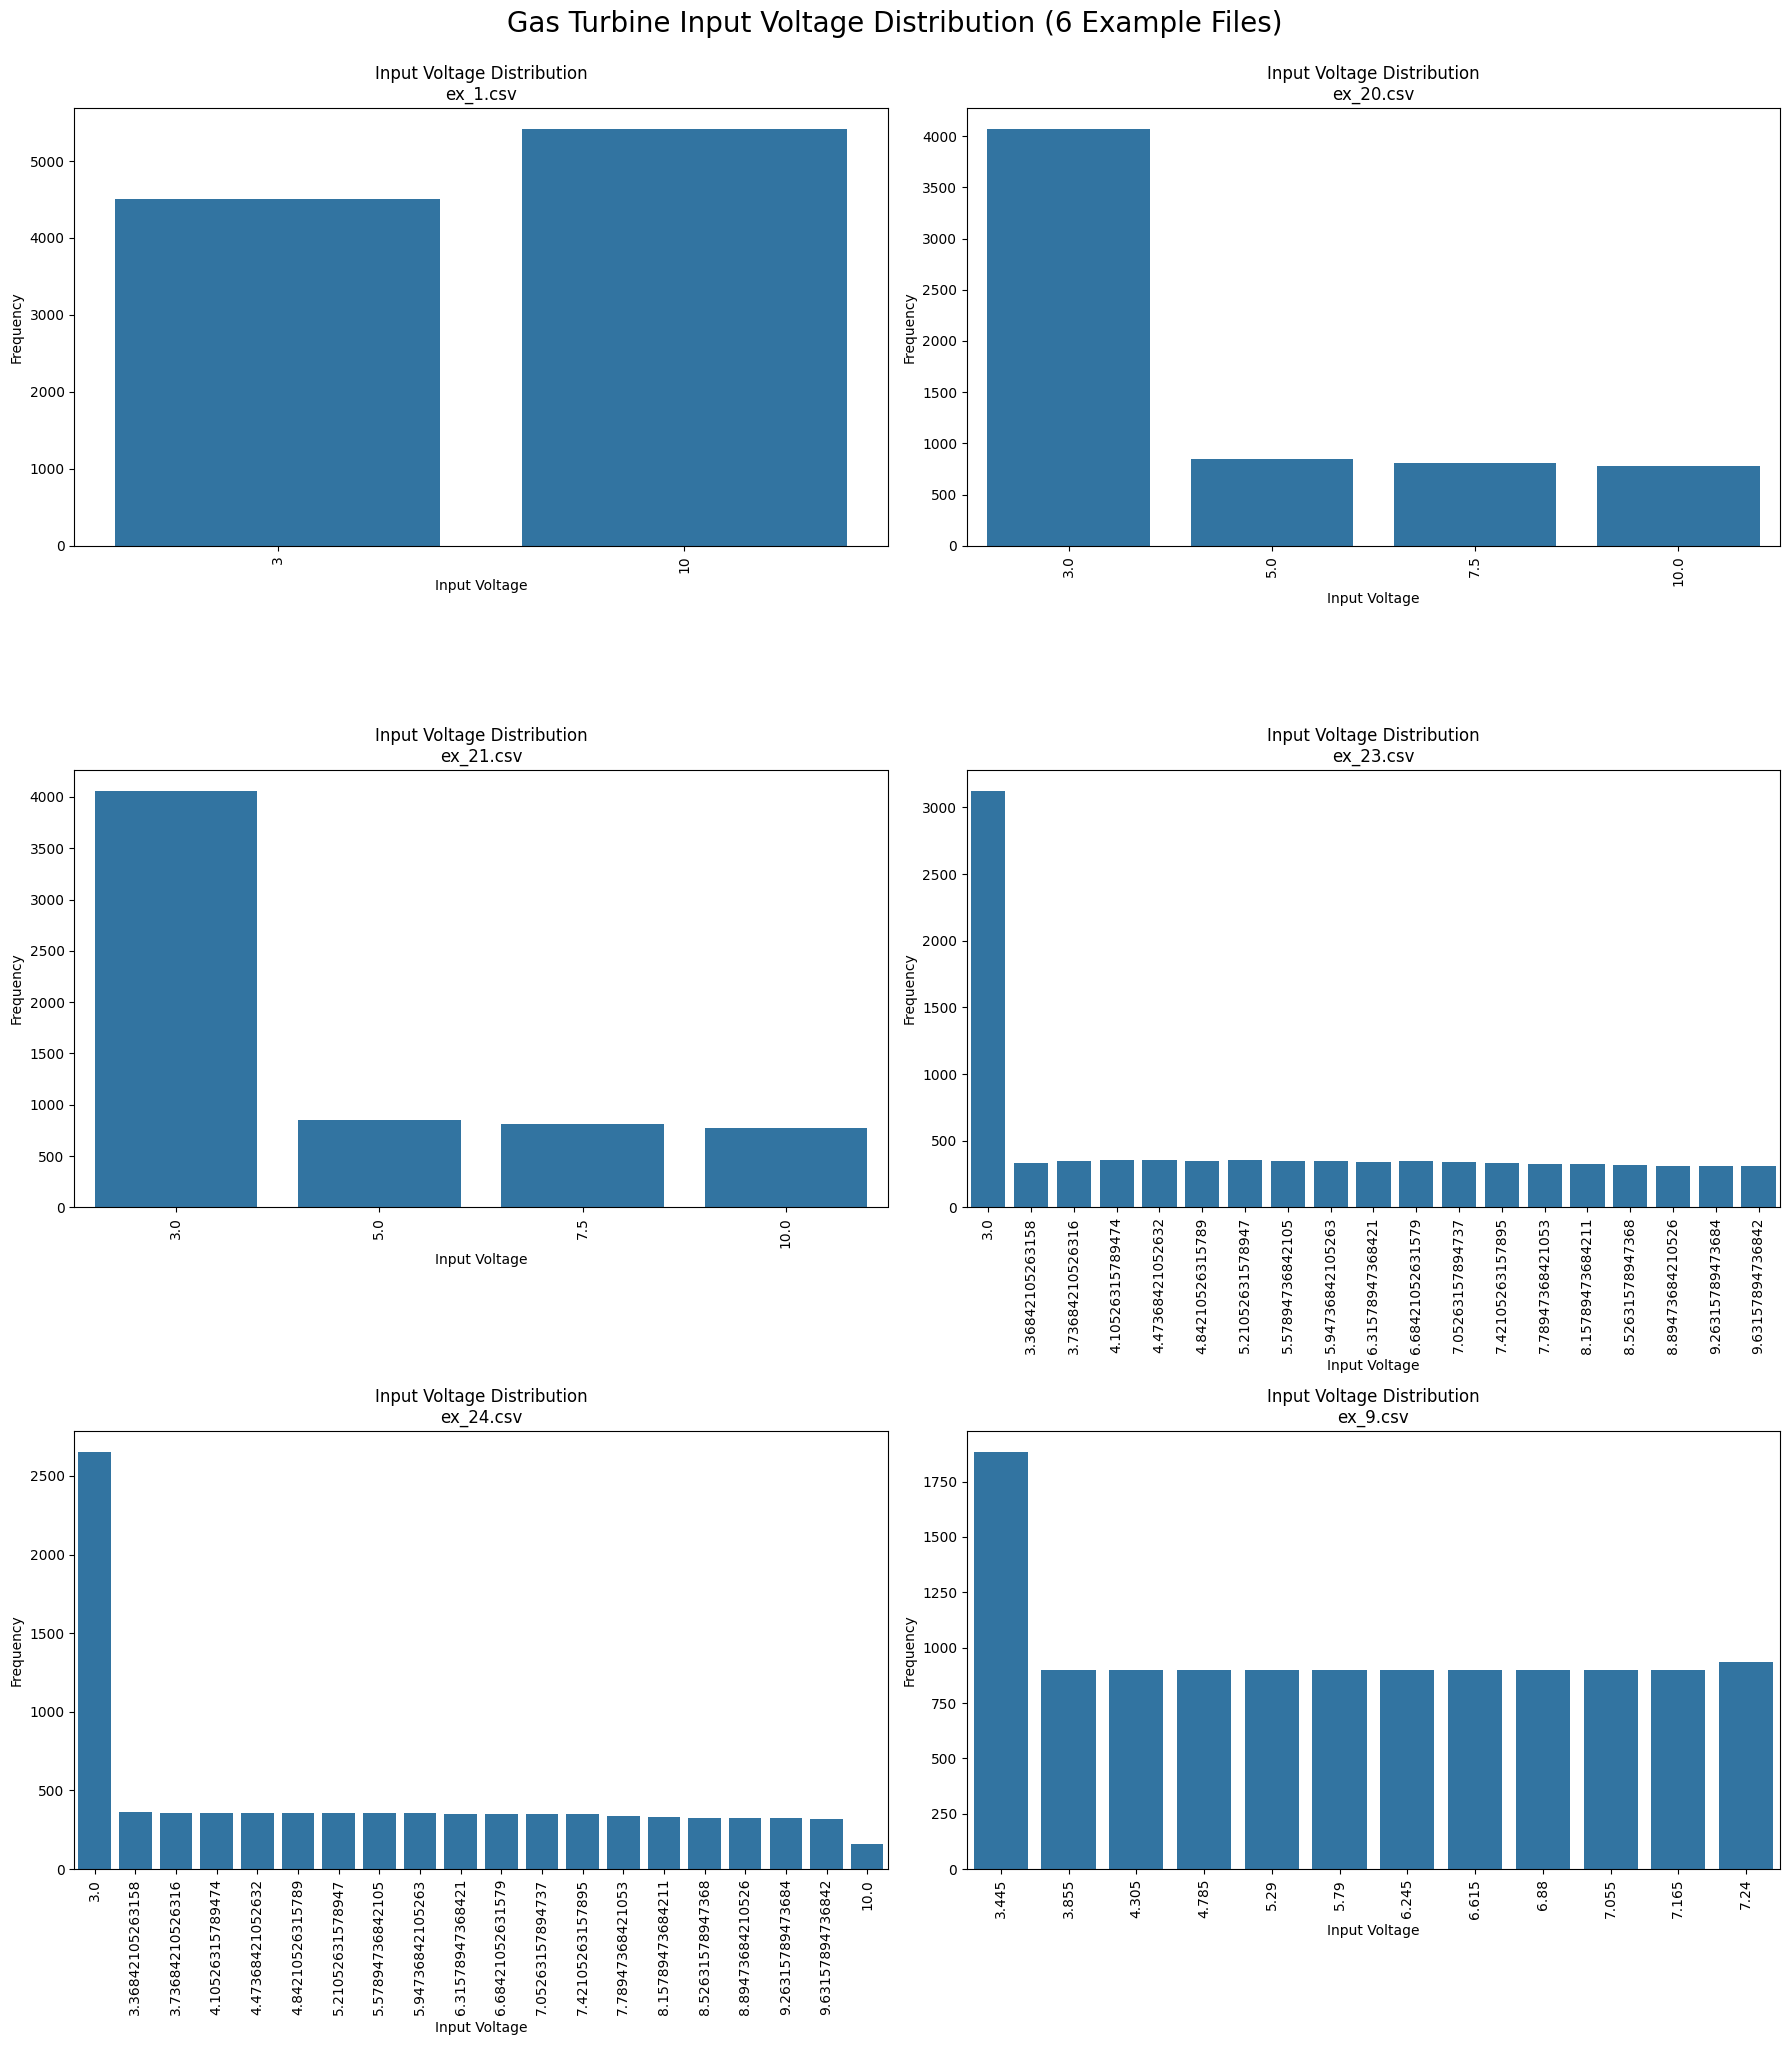

In [21]:
# plot input voltage for 6 example files
plt.figure(figsize=(18, 20))
for i, file in enumerate(example_files, 1):
    data = pd.read_csv(file)
    plt.subplot(3, 2, i)
    sns.barplot(x=data['input_voltage'].value_counts().index, 
                y=data['input_voltage'].value_counts().values)
    plt.xlabel('Input Voltage')
    plt.ylabel('Frequency')
    # rotate x-axis labels
    plt.xticks(rotation=90)
    plt.title(f'Input Voltage Distribution\n{file.split("/")[-1]}')
    plt.tight_layout()
plt.suptitle('Gas Turbine Input Voltage Distribution (6 Example Files)', fontsize=20, y=1.02)
plt.show()

In [12]:
# combining all the csvs into one
import glob
csv_files = glob.glob("../data/train/*.csv")
df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)
df = pd.concat(df_list, ignore_index=True)

df.head()

,time,input_voltage,el_power
0,810.07028,10.0,1228.791720
1,811.06938,10.0,1223.041745
2,812.06848,10.0,1244.960866
3,813.06758,10.0,1229.259058
4,814.06668,10.0,1248.117024


In [15]:
df['time'] = pd.to_datetime(df['time'])
df.head()

,time,input_voltage,el_power
0,1970-01-01 00:00:00.000000810,10.0,1228.791720
1,1970-01-01 00:00:00.000000811,10.0,1223.041745
2,1970-01-01 00:00:00.000000812,10.0,1244.960866
3,1970-01-01 00:00:00.000000813,10.0,1229.259058
4,1970-01-01 00:00:00.000000814,10.0,1248.117024


In [13]:
df.describe()

,time,input_voltage,el_power
count,52940.000000,52940.000000,52940.000000
mean,5606.444209,5.505534,1843.315949
std,2960.330233,2.549721,723.126377
min,810.000000,3.000000,932.837260
25%,3086.930000,3.000000,1205.743900
50%,5431.033890,4.842105,1605.753998
75%,7782.301370,7.421053,2399.419112
max,12636.840000,10.000000,3249.891217


In [14]:
# print first 6 rows for each csv file
for file in csv_files:
    data = pd.read_csv(file)
    data['time'] = pd.to_datetime(data['time'])
    print(f"\nFile: {file}")
    print(data.head(6))


File: ../data/train\ex_1.csv
                           time  input_voltage     el_power
0 1970-01-01 00:00:00.000000810             10  1228.791720
1 1970-01-01 00:00:00.000000811             10  1223.041745
2 1970-01-01 00:00:00.000000812             10  1244.960866
3 1970-01-01 00:00:00.000000813             10  1229.259058
4 1970-01-01 00:00:00.000000814             10  1248.117024
5 1970-01-01 00:00:00.000000815             10  1262.974403

File: ../data/train\ex_20.csv
                           time  input_voltage     el_power
0 1970-01-01 00:00:00.000000849            3.0  1238.511285
1 1970-01-01 00:00:00.000000850            3.0  1149.563728
2 1970-01-01 00:00:00.000000851            3.0  1226.959165
3 1970-01-01 00:00:00.000000852            3.0  1158.086961
4 1970-01-01 00:00:00.000000853            3.0  1230.435294
5 1970-01-01 00:00:00.000000854            3.0  1144.838709

File: ../data/train\ex_21.csv
                           time  input_voltage     el_power
0 1970-0